# Lecture 20 · A 1-D GAN minimax toy

**Goal** · train a tiny generator $G$ and discriminator $D$ on a 1-D Gaussian target
($\mu=4,\ \sigma=0.5$), watch the generated distribution creep onto the target, and
confirm the equilibrium fact: when $p_g=p_{\text{data}}$ the optimal discriminator is
$D^*(x)=\dfrac{p_{\text{data}}(x)}{p_{\text{data}}(x)+p_g(x)}=\tfrac12$ everywhere.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ---- 1-D target: a Gaussian at mu=4, sigma=0.5 -------------------------------
MU, SIGMA = 4.0, 0.5
def sample_real(n):
    return MU + SIGMA * torch.randn(n, 1)

Z_DIM = 1
def sample_z(n):
    return torch.randn(n, Z_DIM)   # noise prior N(0, 1)

print(f"target: N(mu={MU}, sigma={SIGMA})")

target: N(mu=4.0, sigma=0.5)


## The two players

- **Generator** $G:z\mapsto x$ turns noise into samples.
- **Discriminator** $D:x\mapsto$ logit; $\sigma(D(x))$ is its "probability real".

Both are tiny MLPs. We use `BCEWithLogitsLoss` for numerical stability.

In [2]:
def mlp(sizes, out_act=None):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2:
            layers.append(nn.LeakyReLU(0.2))
    return nn.Sequential(*layers)

G = mlp([Z_DIM, 32, 32, 1])      # z -> x
D = mlp([1, 32, 32, 1])          # x -> logit
opt_G = torch.optim.Adam(G.parameters(), lr=2e-3, betas=(0.5, 0.9))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-3, betas=(0.5, 0.9))
bce = nn.BCEWithLogitsLoss()
print(G, "\n", D)

Sequential(
  (0): Linear(in_features=1, out_features=32, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): LeakyReLU(negative_slope=0.2)
  (4): Linear(in_features=32, out_features=1, bias=True)
) 
 Sequential(
  (0): Linear(in_features=1, out_features=32, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): LeakyReLU(negative_slope=0.2)
  (4): Linear(in_features=32, out_features=1, bias=True)
)


## The minimax game

$$\min_G\max_D\; \mathbb{E}_{x\sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z}[\log(1-D(G(z)))]$$

Each step we **alternate**: one $D$ update (push real$\to$1, fake$\to$0), then one $G$
update. For $G$ we use the **non-saturating** loss $-\log D(G(z))$ (label the fakes as
"real") — it gives strong gradients early when $D$ easily rejects the generator.

In [3]:
BATCH, STEPS = 256, 1500
snapshots, snap_at = {}, [0, 100, 400, STEPS]
hist = {"step": [], "gen_mean": [], "gen_std": [], "D_real": [], "D_fake": []}

for step in range(STEPS + 1):
    # ---- D step: real -> 1, fake -> 0 ----
    x_real = sample_real(BATCH)
    x_fake = G(sample_z(BATCH)).detach()
    loss_D = bce(D(x_real), torch.ones(BATCH, 1)) + bce(D(x_fake), torch.zeros(BATCH, 1))
    opt_D.zero_grad(); loss_D.backward(); opt_D.step()

    # ---- G step: non-saturating, label fakes as "real" ----
    x_fake = G(sample_z(BATCH))
    loss_G = bce(D(x_fake), torch.ones(BATCH, 1))     # = -log sigma(D(G(z)))
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    if step in snap_at:
        snapshots[step] = G(sample_z(4000)).detach().numpy().ravel()
    if step % 25 == 0:
        with torch.no_grad():
            gen = G(sample_z(4000))
            d_real = torch.sigmoid(D(sample_real(4000))).mean().item()
            d_fake = torch.sigmoid(D(gen)).mean().item()
        hist["step"].append(step)
        hist["gen_mean"].append(gen.mean().item())
        hist["gen_std"].append(gen.std().item())
        hist["D_real"].append(d_real); hist["D_fake"].append(d_fake)

print(f"final generated: mean={hist['gen_mean'][-1]:.3f} (target {MU}),  "
      f"std={hist['gen_std'][-1]:.3f} (target {SIGMA})")
print(f"final D(real)={hist['D_real'][-1]:.3f},  D(fake)={hist['D_fake'][-1]:.3f}  "
      f"(both -> 0.5 at equilibrium)")

final generated: mean=4.048 (target 4.0),  std=0.361 (target 0.5)
final D(real)=0.518,  D(fake)=0.518  (both -> 0.5 at equilibrium)


## 1 · The generated distribution creeps onto the target

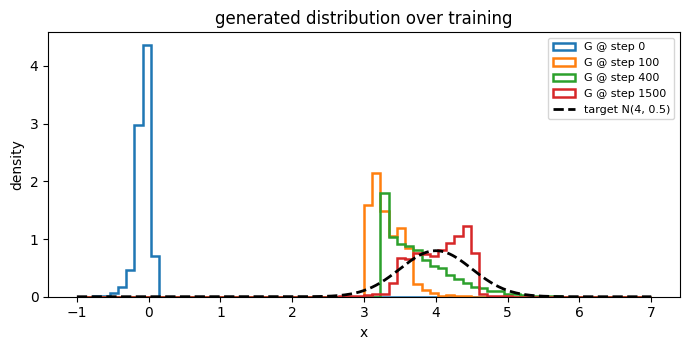

In [4]:
grid = np.linspace(-1.0, 7.0, 400)
true_pdf = np.exp(-0.5 * ((grid - MU) / SIGMA) ** 2) / (SIGMA * np.sqrt(2 * np.pi))

plt.figure(figsize=(7, 3.6))
for s in snap_at:
    plt.hist(snapshots[s], bins=70, range=(-1.0, 7.0), density=True,
             histtype="step", lw=1.8, label=f"G @ step {s}")
plt.plot(grid, true_pdf, "k--", lw=2, label="target N(4, 0.5)")
plt.xlabel("x"); plt.ylabel("density"); plt.legend(fontsize=8)
plt.title("generated distribution over training"); plt.tight_layout(); plt.show()

## 2 · The discriminator settles toward $0.5$

As $p_g\to p_{\text{data}}$, real and fake become indistinguishable, so $D$'s output on
both collapses to $0.5$ — the game reaches its equilibrium $D^*=\tfrac12$.

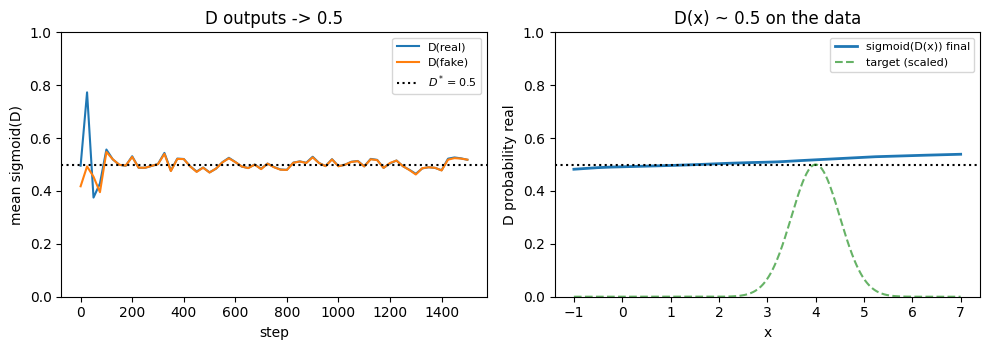

mean |sigmoid(D(x)) - 0.5| over the data region: 0.018


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

ax[0].plot(hist["step"], hist["D_real"], label="D(real)")
ax[0].plot(hist["step"], hist["D_fake"], label="D(fake)")
ax[0].axhline(0.5, color="k", ls=":", label="$D^*=0.5$")
ax[0].set_xlabel("step"); ax[0].set_ylabel("mean sigmoid(D)")
ax[0].set_ylim(0, 1); ax[0].legend(fontsize=8); ax[0].set_title("D outputs -> 0.5")

# D(x) across the data region at the end of training
with torch.no_grad():
    dvals = torch.sigmoid(D(torch.tensor(grid, dtype=torch.float32).view(-1, 1))).numpy().ravel()
ax[1].plot(grid, dvals, lw=2, label="sigmoid(D(x)) final")
ax[1].axhline(0.5, color="k", ls=":")
ax[1].plot(grid, true_pdf / true_pdf.max() * 0.5, "g--", alpha=0.6, label="target (scaled)")
ax[1].set_xlabel("x"); ax[1].set_ylabel("D probability real")
ax[1].set_ylim(0, 1); ax[1].legend(fontsize=8); ax[1].set_title("D(x) ~ 0.5 on the data")
plt.tight_layout(); plt.show()

print("mean |sigmoid(D(x)) - 0.5| over the data region: "
      f"{np.abs(dvals - 0.5)[(grid > 3) & (grid < 5)].mean():.3f}")

## Takeaway
- A GAN is a **minimax game**: $D$ tries to separate real from fake, $G$ tries to fool $D$.
- The **non-saturating** $G$ loss $-\log D(G(z))$ keeps gradients healthy while $G$ is bad.
- At the fixed point $p_g=p_{\text{data}}$, the discriminator can do no better than a coin
  flip: $D^*(x)=\tfrac12$ — exactly what the plots show as training converges.